<a href="https://colab.research.google.com/github/tanishkshindepatil01/ai-text-analytics-coursework-team16-task1/blob/main/AI%26TA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Medical Question Answering — PubMedQA

**Objective:** Analyse how different text representations and AI methods affect the quality of answers to medical questions.

**Dataset:** PubMedQA (expert-annotated subset, 1,000 examples)  
**Task type:** 3-class answer classification (yes / no / maybe)

## Step 0 — Install & Import

We will install and import all essential machine learning and NLP libraries, then set global random seeds to ensure fully reproducible results.

In [1]:
import os
import re
import json
import math
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score
)

try:
    import torch
    from transformers import (
        AutoTokenizer,
        AutoModel,
        AutoModelForSequenceClassification
    )
    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    SBERT_OK = True
except Exception:
    SBERT_OK = False

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("All main libraries imported successfully.")
print(f"Random seed set to {RANDOM_SEED}")
print(f"Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"SentenceTransformers available: {SBERT_OK}")

All main libraries imported successfully.
Random seed set to 42
Transformers available: True
SentenceTransformers available: True


In [2]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
print("imbalanced-learn installed and imported.")

imbalanced-learn installed and imported.


The environment setup is complete and we have verified that PyTorch and Hugging Face Transformers are active and available.

## Step 1 — Load & Explore Data

### 1.1 Loading & Previewing the JSON

We will load the raw JSON dataset from disk and print a quick preview of a single record to inspect the data structure.

In [3]:
DATA_PATH = "/content/data/ori_pqal.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total records: {len(data)}")

first_key = list(data.keys())[0]
print(f"\nExample PMID: {first_key}")
print(json.dumps(data[first_key], indent=2)[:800])

Total records: 1000

Example PMID: 21645374
{
  "QUESTION": "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?",
  "CONTEXTS": [
    "Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.",
    "The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madaga


All 1,000 records loaded successfully. Each record contains a medical question, context paragraphs, a long answer, and a final decision label.

### 1.2 Converting to a Pandas DataFrame

We will iterate through the raw JSON and convert it into a structured Pandas DataFrame while checking for any missing values.

In [4]:
rows = []
for pmid, info in data.items():
    contexts = info.get("CONTEXTS", [])
    rows.append({
        "pmid": pmid,
        "question": info.get("QUESTION", ""),
        "context_list": contexts,
        "context": " ".join(contexts) if isinstance(contexts, list) else str(contexts),
        "long_answer": info.get("LONG_ANSWER", ""),
        "label": str(info.get("final_decision", "")).lower().strip()
    })

df = pd.DataFrame(rows)
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


DataFrame shape: (1000, 6)
Columns: ['pmid', 'question', 'context_list', 'context', 'long_answer', 'label']

Missing values:
pmid            0
question        0
context_list    0
context         0
long_answer     0
label           0
dtype: int64


The DataFrame contains 1,000 rows and 6 columns with absolutely zero missing values.

### 1.3 Checking Label Distribution

We will run a quick check on our target variable to see how the three labels are distributed across the dataset.

In [5]:
print(f"\nLabel distribution:")
print(df["label"].value_counts())


Label distribution:
label
yes      552
no       338
maybe    110
Name: count, dtype: int64


The dataset is imbalanced with 552 'yes', 338 'no', and 110 'maybe' labels, which will be an important factor in our modelling strategy.

### 1.4 Feature Engineering for Exploration

We will calculate word counts for our questions, contexts, and long answers so we can visualise their distributions.

In [6]:
df["question_len"] = df["question"].str.split().str.len()
df["context_len"] = df["context"].str.split().str.len()
df["long_answer_len"] = df["long_answer"].str.split().str.len()
df["num_contexts"] = df["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Feature columns added: question_len, context_len, long_answer_len, num_contexts")

Feature columns added: question_len, context_len, long_answer_len, num_contexts


The DataFrame now has the raw length and sentence count features needed for our visualisation grid.

### 1.5 Data Exploration Visualisations

We will build a 6-panel visualisation grid showing label distribution, text length histograms by label, context sentence counts, boxplots, and a scatter plot.

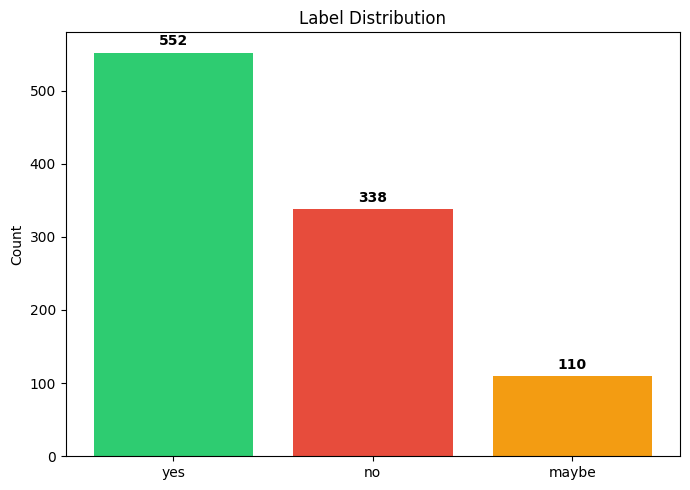

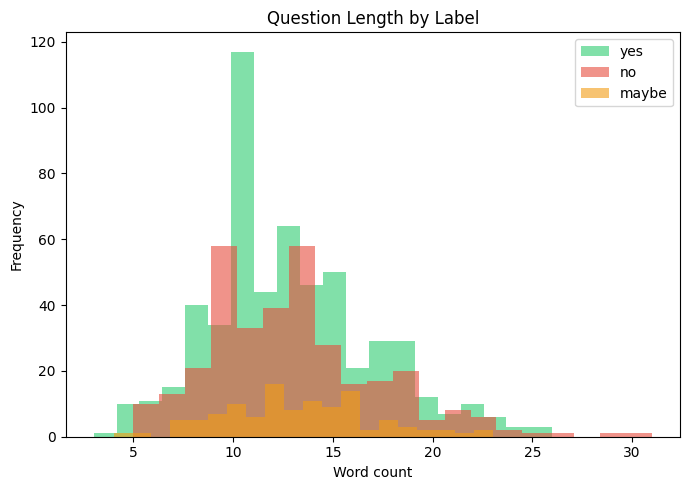

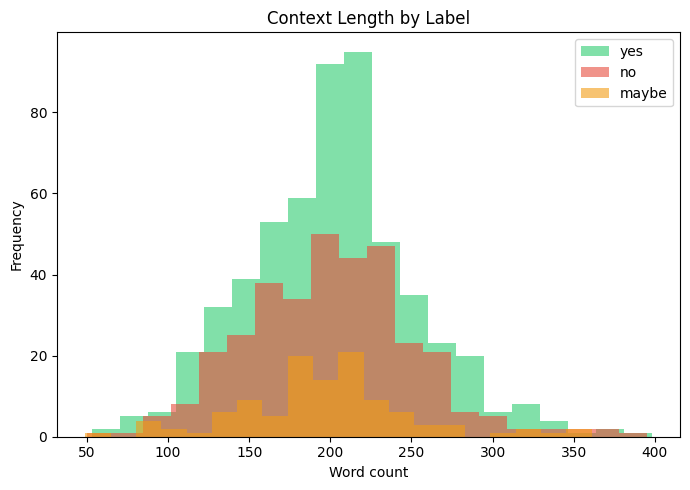

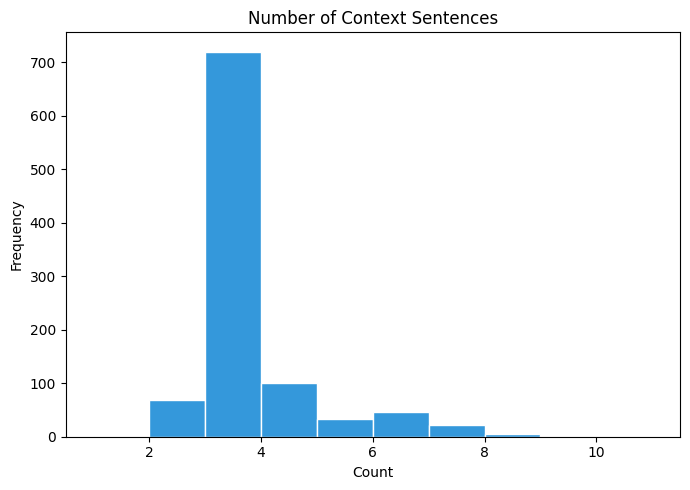

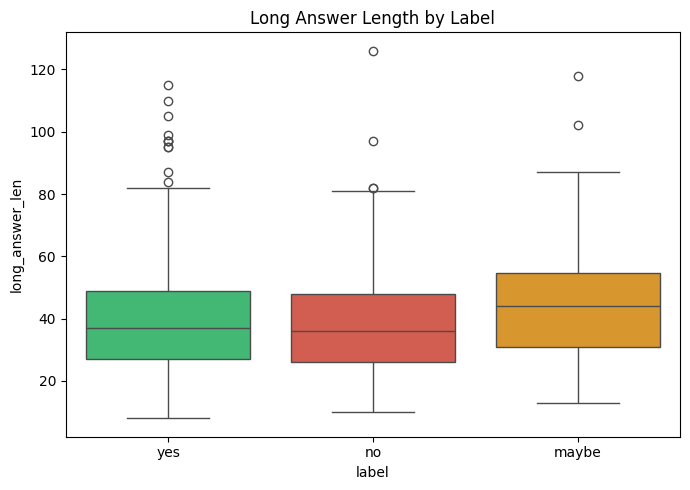

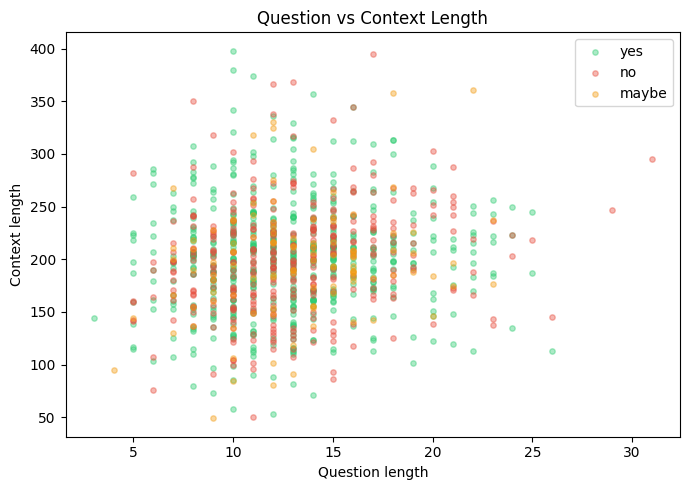

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

colors = {"yes": "#2ecc71", "no": "#e74c3c", "maybe": "#f39c12"}

plt.figure(figsize=(7, 5))
label_counts = df["label"].value_counts()
plt.bar(label_counts.index, label_counts.values,
        color=[colors.get(lab, "#3498db") for lab in label_counts.index])
plt.title("Label Distribution")
plt.ylabel("Count")

for i, (lab, cnt) in enumerate(zip(label_counts.index, label_counts.values)):
    plt.text(i, cnt + 10, str(cnt), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_1_label_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["question_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Question Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_2_question_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["context_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Context Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_3_context_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(df["num_contexts"], bins=range(1, 12), color="#3498db", edgecolor="white")
plt.title("Number of Context Sentences")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_4_num_context_sentences.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="label",
    y="long_answer_len",
    order=["yes", "no", "maybe"],
    palette=[colors["yes"], colors["no"], colors["maybe"]]
)
plt.title("Long Answer Length by Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_5_long_answer_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]
    plt.scatter(
        subset["question_len"],
        subset["context_len"],
        alpha=0.4,
        label=lab,
        color=colors[lab],
        s=15
    )

plt.title("Question vs Context Length")
plt.xlabel("Question length")
plt.ylabel("Context length")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_6_question_vs_context_length.png"), dpi=300, bbox_inches="tight")
plt.show()

The visualisations clearly show the label imbalance and how context lengths are distributed, giving us a solid understanding of the dataset before preprocessing.

### 1.6 Descriptive Statistics Summary

We will print a rounded table of descriptive statistics to get the exact numerical summaries for our text lengths.

In [8]:
print("\nDescriptive statistics:")
display(df[["question_len", "context_len", "long_answer_len", "num_contexts"]].describe().round(1))


Descriptive statistics:


,question_len,context_len,long_answer_len,num_contexts
count,1000.0,1000.0,1000.0,1000.0
mean,12.9,200.2,39.7,3.4
std,4.1,51.8,17.2,1.1
min,3.0,49.0,8.0,1.0
25%,10.0,166.8,27.0,3.0
50%,13.0,200.5,37.0,3.0
75%,15.0,228.0,49.0,3.0
max,31.0,398.0,126.0,9.0


The average context length is roughly 200 words with a max of 398, confirming we are well within manageable tokeniser limits.

## Step 2 — Preprocessing & Feature Engineering

### 2.1 Text Cleaning

We will define a custom cleaning function to lowercase all text and strip out irregular punctuation, then apply it to the main text columns.

In [9]:
df_model = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\-\?\.,:;/%()]", " ", text)
    return text.strip()

df_model["question_clean"] = df_model["question"].apply(clean_text)
df_model["context_clean"] = df_model["context"].apply(clean_text)
df_model["long_answer_clean"] = df_model["long_answer"].apply(clean_text)

print(f"Text cleaning complete. Columns: {[c for c in df_model.columns if 'clean' in c]}")

Text cleaning complete. Columns: ['question_clean', 'context_clean', 'long_answer_clean']


Text cleaning is complete and our core text columns are now fully standardised for consistent downstream processing.

### 2.2 Input Variants & Label Encoding

We will generate three distinct input text variants (question only, question + context, and question + context + answer) and encode the labels as integers.

In [10]:
df_model["text_q_only"] = "question: " + df_model["question_clean"]
df_model["text_q_ctx"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
)
df_model["text_q_ctx_ans"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
    + " answer: " + df_model["long_answer_clean"]
)

label2id = {"no": 0, "maybe": 1, "yes": 2}
id2label = {0: "no", 1: "maybe", 2: "yes"}
df_model["label_id"] = df_model["label"].map(label2id)
df_model["question_len"] = df_model["question_clean"].apply(lambda x: len(x.split()))
df_model["context_len"] = df_model["context_clean"].apply(lambda x: len(x.split()))
df_model["long_answer_len"] = df_model["long_answer_clean"].apply(lambda x: len(x.split()))
df_model["num_contexts"] = df_model["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 1)

assert df_model["label_id"].isna().sum() == 0, "Unmapped labels found!"

print(f"Input variants created. Shape: {df_model.shape}")
print(f"Label distribution: {df_model['label_id'].value_counts().sort_index().to_dict()}")

Input variants created. Shape: (1000, 17)
Label distribution: {0: 338, 1: 110, 2: 552}


Our three text permutations are built, lengths are recalculated based on clean text, and the assertion check confirms no unmapped labels remain.

### 2.3 Handcrafted NLP Features

We will engineer handcrafted NLP features to detect specific vocabulary patterns like negation, causation, comparison, and hedging language in our texts.

In [11]:
df_model["has_negation"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x.split() for w in ["no", "not", "without", "lack", "absence"]))
)
df_model["has_causal"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["cause", "effect", "impact", "influence", "affect", "lead to"]))
)
df_model["has_comparison"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["compar", "differ", "versus", "vs", "better", "worse"]))
)
df_model["has_association"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["associat", "correlat", "relat", "link"]))
)
df_model["has_risk"] = df_model["question_clean"].apply(
    lambda x: int("risk" in x)
)
df_model["context_evidence_strength"] = df_model["long_answer_clean"].apply(
    lambda x: int(any(w in x for w in ["significant", "strongly", "clearly", "demonstrated"]))
)
df_model["answer_hedging"] = df_model["long_answer_clean"].apply(
    lambda x: int(any(w in x for w in ["may", "might", "suggest", "possibly", "further study", "inconclusive"]))
)

print("Preprocessing complete")
print(f"Shape: {df_model.shape}")
print(f"Label distribution:\n{df_model['label_id'].value_counts().sort_index()}")
print(f"\nSample cleaned text (first row):")
print(df_model["text_q_ctx"].iloc[0][:200])

Preprocessing complete
Shape: (1000, 24)
Label distribution:
label_id
0    338
1    110
2    552
Name: count, dtype: int64

Sample cleaned text (first row):
question: do mitochondria play a role in remodelling lace plant leaves during programmed cell death? context: programmed cell death (pcd) is the regulated death of cells within an organism. the lace p


Preprocessing is complete and the DataFrame has expanded to 24 columns with all handcrafted features added alongside the verified label distribution.